"sb2" NN for solubility prediction

Extracting chemical structures as Fingerprints...

Starting Training Run...
Epoch 40: Train MSE 0.2233 | Test MSE 0.2563
Final Results -> R2: 0.7728


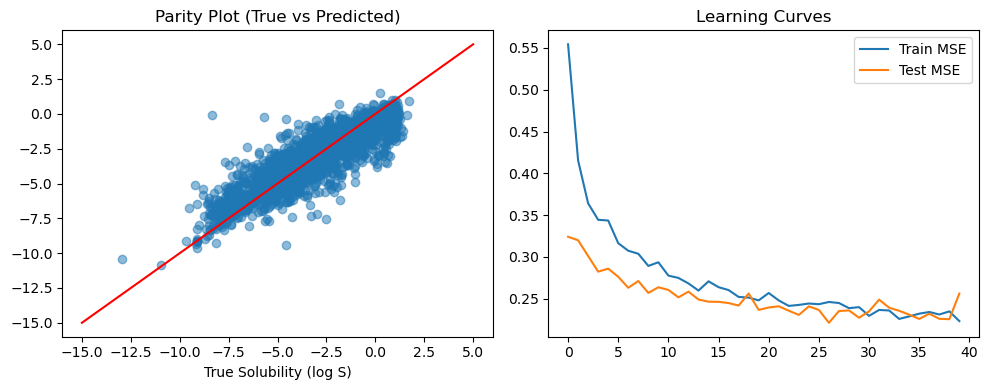

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
dataset = pd.read_csv('curated-solubility-dataset.csv')

def smiles_to_fp(smiles, n_bits=256):
    """Convert a SMILES string into a Morgan fingerprint vector (ECFP4)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Radius 2 = ECFP4 standard 
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
        return np.array(fp)
    return np.zeros(n_bits)

print("Extracting chemical structures as Fingerprints...")
fingerprints = np.stack(dataset['SMILES'].apply(smiles_to_fp))

numeric_cols = dataset.select_dtypes(include=np.number).columns
X_numeric = dataset[numeric_cols].drop(columns=['Solubility']).values

X_combined = np.hstack([X_numeric, fingerprints])
y = dataset['Solubility']
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_X.fit_transform(X_combined)
y_std = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

joblib.dump(scaler_X, 'sb2_scaler_X.joblib')
joblib.dump(scaler_y, 'sb2_scaler_y.joblib')

X_train, X_test, y_train, y_test = train_test_split(X_std, y_std, test_size=0.25, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view([-1, 1])
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view([-1, 1])

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=16, shuffle=False)


network = nn.Sequential(
    nn.Linear(X_train.shape[1], 128), 
    nn.BatchNorm1d(128),              
    nn.ReLU(),
    nn.Dropout(0.5),                  
    
    nn.Linear(128, 64),
    nn.ReLU(),
    
    nn.Linear(64, 1)
)

optimizer = torch.optim.Adam(network.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.MSELoss()
epochs = 40
best_test_mse = float('inf') 
patience = 15
counter = 0
history_train = []
history_test = []

print("\nStarting Training Run...")
for epoch in range(epochs):
    network.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        out = network(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
    
    # Validation at end of epoch for clean metrics
    network.eval()
    test_loss = 0.0
    with torch.no_grad():
        for Xbt, ybt in test_loader:
            test_loss += criterion(network(Xbt), ybt).item() * len(ybt)
            
    mse_train = train_loss / len(X_train)
    mse_test = test_loss / len(X_test)
    history_train.append(mse_train)
    history_test.append(mse_test)

    if mse_test < best_test_mse:
        best_test_mse = mse_test
        torch.save(network.state_dict(), 'sb2_weights.pt')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\nTraining interrupted: Early stopping at epoch {epoch}")
            break
    print(f"Epoch {epoch+1}: Train MSE {mse_train:.4f} | Test MSE {mse_test:.4f}", end="\r")

network.load_state_dict(torch.load('sb2_weights.pt'))
network.eval()

with torch.no_grad():
    y_pred_scaled = network(X_test_t).numpy().flatten()
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f"\nFinal Results -> R2: {r2_score(y_true_real, y_pred_real):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(y_true_real, y_pred_real, 'o', alpha=0.5)
ax[0].plot([-15, 5], [-15, 5], 'r-')
ax[0].set_title('Parity Plot (True vs Predicted)')
ax[0].set_xlabel('True Solubility (log S)')
ax[1].plot(history_train, label='Train MSE')
ax[1].plot(history_test, label='Test MSE')
ax[1].set_title('Learning Curves')
ax[1].legend()
plt.tight_layout()
plt.show()

#Epoch 40: Train MSE 0.2233 | Test MSE 0.2563
#Final Results -> R2: 0.7728